MEMULAI PIPELINE DATA ANALYTICS: INFLASI PANGAN

[1/4] Mengekstrak dan Membersihkan Data Mentah
Berhasil menggabungkan dan membersihkan 27850 baris data.

[2/4] Melakukan Analisis Volatilitas (Month-over-Month)
Logika Time-Series dan Volatilitas berhasil dihitung.
Kalkulasi Moving Average (Tren 3 Bulanan) berhasil ditambahkan.

[3/4] Membuat Visualisasi Grafik Tren


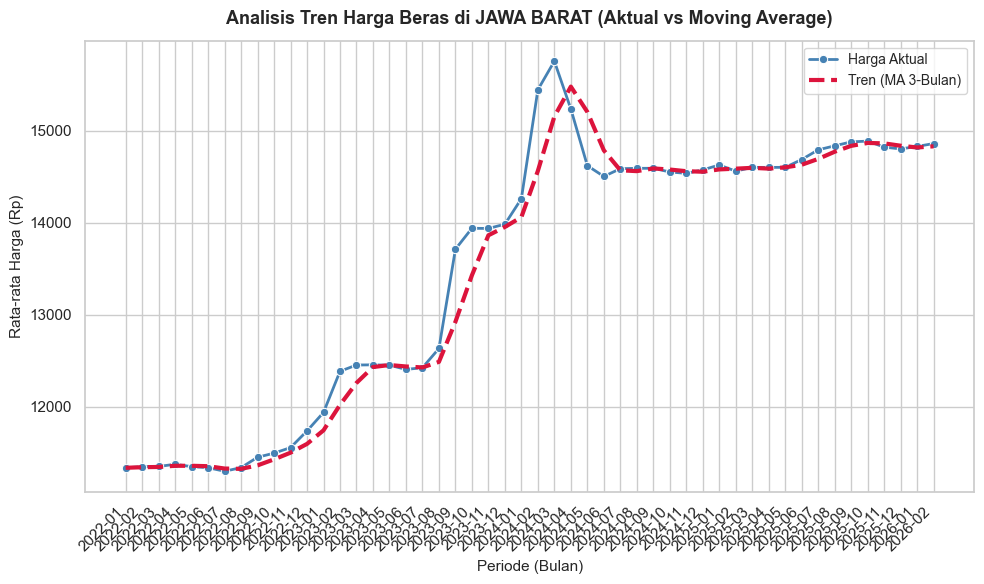

Grafik Jawa Barat berhasil disimpan: d:\ayang\IN\pro\Proyek_Inflasi_Pangan\Visualisasi_Tren_MA_Beras_Jabar.png


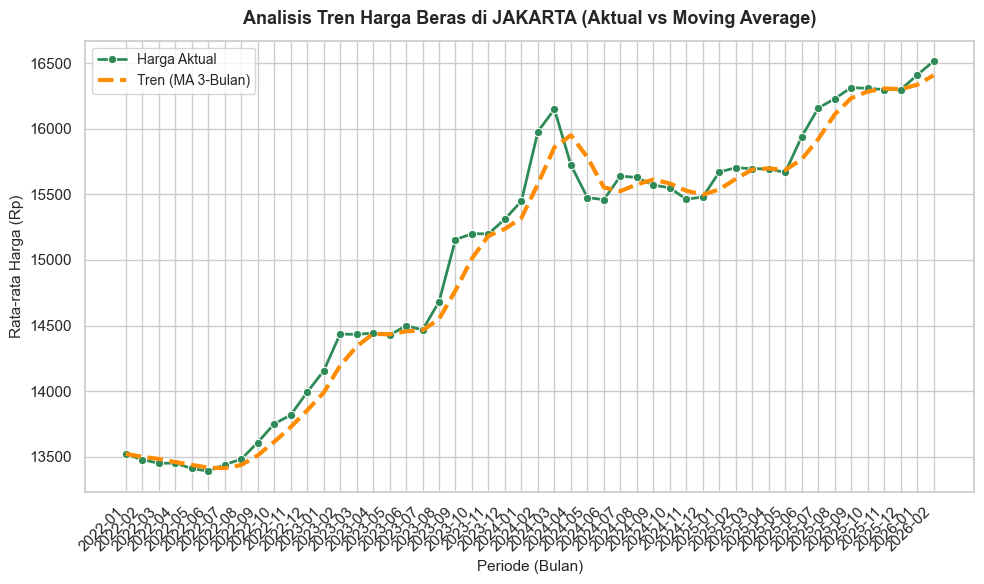

Grafik Jakarta berhasil disimpan: d:\ayang\IN\pro\Proyek_Inflasi_Pangan\Visualisasi_Tren_MA_Beras_Jakarta.png

 Membuat Grafik Tren Harga Murni


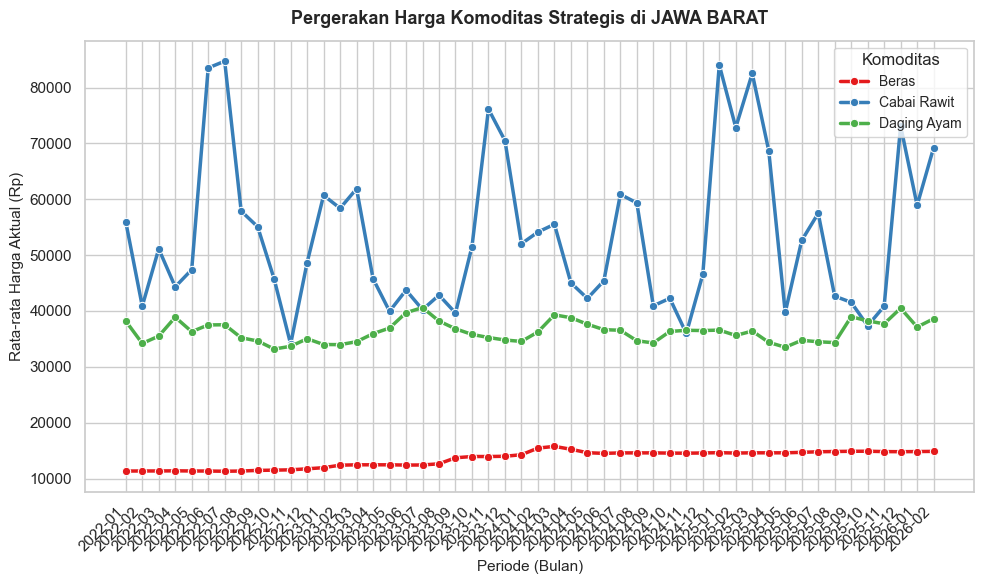

Grafik Harga Murni Jabar berhasil disimpan: d:\ayang\IN\pro\Proyek_Inflasi_Pangan\Visualisasi_Harga_Murni_Jabar.png


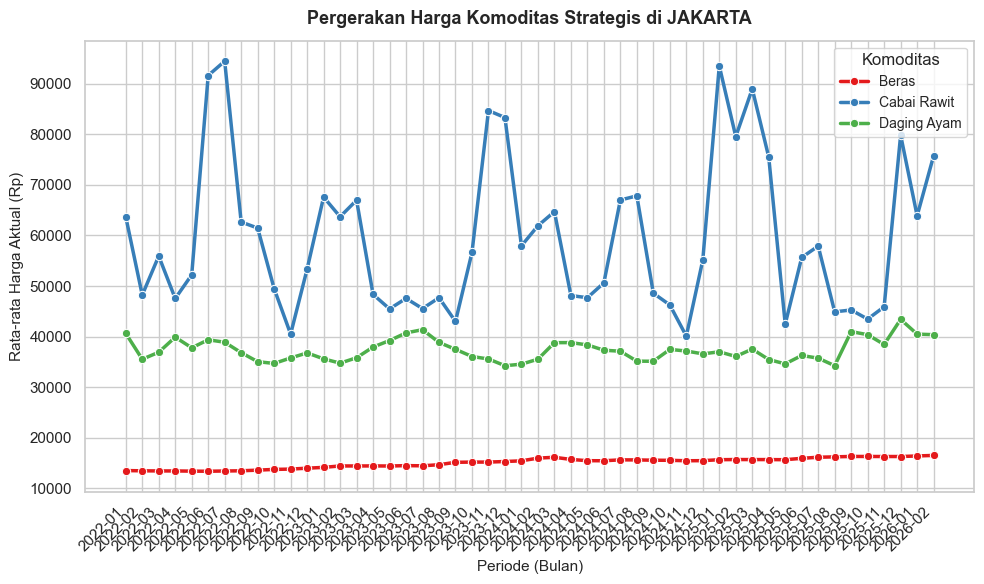

Grafik Harga Murni Jakarta berhasil disimpan: d:\ayang\IN\pro\Proyek_Inflasi_Pangan\Visualisasi_Harga_Murni_Jakarta.png

[4/4] Mengekstrak Insight Data (Top 5 Volatilitas Ekstrem)

TOP 5 VOLATILITAS HARGA TEREKSTREM (GABUNGAN JABAR & JAKARTA)
+---------+-----------------+------------------+--------------------+-------------------+---------------------+-----------------------------------+
| Bulan   | Province_Name   | Commodity_Name   |   Harga_Bulan_Lalu |   Harga_Bulan_Ini |   Pertumbuhan_MoM_% | Status_Volatilitas                |
+=========+=================+==================+====================+===================+=====================+===================================+
| 2025-01 | Jawa Barat      | Cabai Rawit      |            46546.8 |           84057.4 |               80.59 | Lonjakan Ekstrem (Inflasi Tinggi) |
+---------+-----------------+------------------+--------------------+-------------------+---------------------+-----------------------------------+
| 2025-12 | Jawa 

In [3]:
import pandas as pd
import numpy as np
import glob
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("MEMULAI PIPELINE DATA ANALYTICS: INFLASI PANGAN")

# TAHAP 1: EKSTRAKSI & TRANSFORMASI DATA (ETL)
print("\n[1/4] Mengekstrak dan Membersihkan Data Mentah")

# Gunakan os.getcwd() untuk Notebook
folder_saat_ini = os.getcwd() 
pola_file = os.path.join(folder_saat_ini, 'komoditas_*.csv')
file_paths = glob.glob(pola_file)

if not file_paths:
    print(f"ERROR: File CSV tidak ditemukan di: {folder_saat_ini}")
    print("Pastikan file komoditas_*.csv ada di folder yang sama dengan notebook ini!")
else:

    # Membaca dan menggabungkan semua file CSV
    df_master = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)
    
    # Filtering Provinsi Target BPS
    target_provinsi = ['Jawa Barat', 'DKI Jakarta']
    if 'Province_Name' in df_master.columns:
        df_master = df_master[df_master['Province_Name'].isin(target_provinsi)]

    # Standarisasi Datetime
    df_master['Date_Param'] = pd.to_datetime(df_master['Date_Param'], errors='coerce')

    # Pembersihan teks pada kolom harga menjadi angka murni
    if 'Price' in df_master.columns and df_master['Price'].dtype == 'object':
        df_master['Price'] = df_master['Price'].str.replace(r'[^\d.]', '', regex=True)
        df_master['Price'] = pd.to_numeric(df_master['Price'], errors='coerce')

    # Time-Series Handling (Mengisi data kosong di hari libur pasar)
    df_master = df_master.sort_values(by=['Province_Name', 'Commodity_Name', 'Date_Param'])
    if 'Price' in df_master.columns:
        df_master['Price'] = df_master.groupby(['Province_Name', 'Commodity_Name'])['Price'].ffill()
    
    df_master = df_master.dropna(subset=['Price']).reset_index(drop=True)
    print(f"Berhasil menggabungkan dan membersihkan {len(df_master)} baris data.")

# TAHAP 2: ANALISIS KOMPUTASI (VOLATILITAS & TREN)
print("\n[2/4] Melakukan Analisis Volatilitas (Month-over-Month)")

# 1. Mengekstrak format Tahun-Bulan (YYYY-MM)
df_master['Bulan'] = df_master['Date_Param'].dt.strftime('%Y-%m')

# 2. Menghitung Rata-rata Harga Bulanan per Komoditas
df_bulanan = df_master.groupby(['Province_Name', 'Commodity_Name', 'Bulan'])['Price'].mean().reset_index()
df_bulanan.rename(columns={'Price': 'Harga_Bulan_Ini'}, inplace=True)
df_bulanan['Harga_Bulan_Ini'] = df_bulanan['Harga_Bulan_Ini'].round(2)

# 3. Menarik Data Harga Bulan Sebelumnya
df_bulanan = df_bulanan.sort_values(by=['Province_Name', 'Commodity_Name', 'Bulan'])
df_bulanan['Harga_Bulan_Lalu'] = df_bulanan.groupby(['Province_Name', 'Commodity_Name'])['Harga_Bulan_Ini'].shift(1)

# 4. Menghitung Persentase Pertumbuhan (Inflasi/Deflasi)
df_bulanan['Pertumbuhan_MoM_%'] = ((df_bulanan['Harga_Bulan_Ini'] - df_bulanan['Harga_Bulan_Lalu']) / df_bulanan['Harga_Bulan_Lalu']) * 100
df_bulanan['Pertumbuhan_MoM_%'] = df_bulanan['Pertumbuhan_MoM_%'].round(2)

# 5. Business Logic: Klasifikasi Status Volatilitas
def tentukan_status(persen):
    if pd.isna(persen): return 'Data Awal (Baseline)'
    elif persen > 10.0: return 'Lonjakan Ekstrem (Inflasi Tinggi)'
    elif persen < -10.0: return 'Penurunan Signifikan (Deflasi)'
    else: return 'Fluktuasi Normal'

df_bulanan['Status_Volatilitas'] = df_bulanan['Pertumbuhan_MoM_%'].apply(tentukan_status)
print("Logika Time-Series dan Volatilitas berhasil dihitung.")

# 6. Menghitung 3-Month Moving Average (Tren Harga)
# Memastikan data diurutkan berdasarkan waktu sebelum menerapkan fungsi rolling
df_bulanan = df_bulanan.sort_values(by=['Province_Name', 'Commodity_Name', 'Bulan'])
df_bulanan['MA_3_Bulan'] = df_bulanan.groupby(['Province_Name', 'Commodity_Name'])['Harga_Bulan_Ini'] \
                                     .transform(lambda x: x.rolling(window=3, min_periods=1).mean().round(2))

print("Kalkulasi Moving Average (Tren 3 Bulanan) berhasil ditambahkan.")

# Menyimpan hasil analisis akhir untuk lampiran portofolio
output_analisis = os.path.join(folder_saat_ini, 'Hasil_Analisis_Inflasi_Bulanan.csv')
df_bulanan.to_csv(output_analisis, index=False)

# TAHAP 3: VISUALISASI DATA
print("\n[3/4] Membuat Visualisasi Grafik Tren")

sns.set_theme(style="whitegrid")

# GRAFIK 1: JAWA BARAT
plt.figure(figsize=(10, 6)) 
df_jabar_beras = df_bulanan[(df_bulanan['Province_Name'] == 'Jawa Barat') & (df_bulanan['Commodity_Name'] == 'Beras')]

sns.lineplot(data=df_jabar_beras, x='Bulan', y='Harga_Bulan_Ini', marker='o', color='steelblue', label='Harga Aktual', linewidth=2)
sns.lineplot(data=df_jabar_beras, x='Bulan', y='MA_3_Bulan', linestyle='--', color='crimson', label='Tren (MA 3-Bulan)', linewidth=3)

plt.title('Analisis Tren Harga Beras di JAWA BARAT (Aktual vs Moving Average)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Periode (Bulan)', fontsize=11)
plt.ylabel('Rata-rata Harga (Rp)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize='10')
plt.tight_layout()

# Tampilkan di layar
plt.show() 

# Baru simpan ke file
output_jabar = os.path.join(folder_saat_ini, 'Visualisasi_Tren_MA_Beras_Jabar.png')
plt.savefig(output_jabar, dpi=300)
plt.close()
print(f"Grafik Jawa Barat berhasil disimpan: {output_jabar}")


# GRAFIK 2: JAKARTA
plt.figure(figsize=(10, 6)) 
df_dki_beras = df_bulanan[(df_bulanan['Province_Name'] == 'DKI Jakarta') & (df_bulanan['Commodity_Name'] == 'Beras')]

sns.lineplot(data=df_dki_beras, x='Bulan', y='Harga_Bulan_Ini', marker='o', color='seagreen', label='Harga Aktual', linewidth=2)
sns.lineplot(data=df_dki_beras, x='Bulan', y='MA_3_Bulan', linestyle='--', color='darkorange', label='Tren (MA 3-Bulan)', linewidth=3)

plt.title('Analisis Tren Harga Beras di JAKARTA (Aktual vs Moving Average)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Periode (Bulan)', fontsize=11)
plt.ylabel('Rata-rata Harga (Rp)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize='10')
plt.tight_layout()

# Tampilkan di layar
plt.show() 

# Baru simpan ke file
output_jakarta = os.path.join(folder_saat_ini, 'Visualisasi_Tren_MA_Beras_Jakarta.png')
plt.savefig(output_jakarta, dpi=300)
plt.close() 
print(f"Grafik Jakarta berhasil disimpan: {output_jakarta}")


# VISUALISASI TREN HARGA MURNI (TANPA MA)
print("\n Membuat Grafik Tren Harga Murni")
komoditas_utama = ['Beras', 'Cabai Rawit', 'Daging Ayam']

# GRAFIK 3: TREN HARGA MURNI - JAWA BARAT
plt.figure(figsize=(10, 6))
df_jabar_murni = df_bulanan[(df_bulanan['Province_Name'] == 'Jawa Barat') & 
                            (df_bulanan['Commodity_Name'].isin(komoditas_utama))]

sns.lineplot(data=df_jabar_murni, x='Bulan', y='Harga_Bulan_Ini', hue='Commodity_Name', marker='o', linewidth=2.5, palette='Set1')
plt.title('Pergerakan Harga Komoditas Strategis di JAWA BARAT', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Periode (Bulan)', fontsize=11)
plt.ylabel('Rata-rata Harga Aktual (Rp)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Komoditas', fontsize='10')
plt.tight_layout()

plt.show()

output_jabar_murni = os.path.join(folder_saat_ini, 'Visualisasi_Harga_Murni_Jabar.png')
plt.savefig(output_jabar_murni, dpi=300)
plt.close()
print(f"Grafik Harga Murni Jabar berhasil disimpan: {output_jabar_murni}")

# GRAFIK 4: TREN HARGA MURNI - JAKARTA
plt.figure(figsize=(10, 6))
df_dki_murni = df_bulanan[(df_bulanan['Province_Name'] == 'DKI Jakarta') & 
                          (df_bulanan['Commodity_Name'].isin(komoditas_utama))]

sns.lineplot(data=df_dki_murni, x='Bulan', y='Harga_Bulan_Ini', hue='Commodity_Name', marker='o', linewidth=2.5, palette='Set1')
plt.title('Pergerakan Harga Komoditas Strategis di JAKARTA', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Periode (Bulan)', fontsize=11)
plt.ylabel('Rata-rata Harga Aktual (Rp)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Komoditas', fontsize='10')
plt.tight_layout()

plt.show()

output_dki_murni = os.path.join(folder_saat_ini, 'Visualisasi_Harga_Murni_Jakarta.png')
plt.savefig(output_dki_murni, dpi=300)
plt.close()
print(f"Grafik Harga Murni Jakarta berhasil disimpan: {output_dki_murni}")

# TAHAP 4: INSIGHT & KESIMPULAN (TOP 5 LONJAKAN HARGA)
print("\n[4/4] Mengekstrak Insight Data (Top 5 Volatilitas Ekstrem)")

from tabulate import tabulate

# Menggunakan Nilai Mutlak (Absolute) untuk mendeteksi anomali ekstrem (Naik/Turun)
df_bulanan['Volatilitas_Absolut'] = df_bulanan['Pertumbuhan_MoM_%'].abs()

# 1. Mengambil Top 5 Volatilitas Tertinggi Gabungan (Jabar & Jakarta)
df_ekstrem = df_bulanan.sort_values(by='Volatilitas_Absolut', ascending=False).head(5)

print("\nTOP 5 VOLATILITAS HARGA TEREKSTREM (GABUNGAN JABAR & JAKARTA)")
print(tabulate(
    df_ekstrem[['Bulan', 'Province_Name', 'Commodity_Name', 'Harga_Bulan_Lalu', 'Harga_Bulan_Ini', 'Pertumbuhan_MoM_%', 'Status_Volatilitas']], 
    headers='keys', 
    tablefmt='grid', 
    showindex=False
))
print("\n") 

# 2. Mengambil Top 5 Volatilitas Tertinggi di Jawa Barat
df_jabar_ekstrem = df_bulanan[df_bulanan['Province_Name'] == 'Jawa Barat'] \
                    .sort_values(by='Volatilitas_Absolut', ascending=False) \
                    .head(5)

print("TOP 5 VOLATILITAS HARGA TEREKSTREM: JAWA BARAT")
print(tabulate(
    df_jabar_ekstrem[['Bulan', 'Commodity_Name', 'Harga_Bulan_Lalu', 'Harga_Bulan_Ini', 'Pertumbuhan_MoM_%', 'Status_Volatilitas']], 
    headers='keys', 
    tablefmt='grid', 
    showindex=False
))
print("\n")

# 3. Mengambil Top 5 Volatilitas Tertinggi di Jakarta
df_dki_ekstrem = df_bulanan[df_bulanan['Province_Name'] == 'DKI Jakarta'] \
                    .sort_values(by='Volatilitas_Absolut', ascending=False) \
                    .head(5)

print("TOP 5 VOLATILITAS HARGA TEREKSTREM: JAKARTA")
print(tabulate(
    df_dki_ekstrem[['Bulan', 'Commodity_Name', 'Harga_Bulan_Lalu', 'Harga_Bulan_Ini', 'Pertumbuhan_MoM_%', 'Status_Volatilitas']], 
    headers='keys', 
    tablefmt='grid', 
    showindex=False
))
# Membersihkan kolom sementara
df_bulanan.drop(columns=['Volatilitas_Absolut'], inplace=True)

print("\nSELURUH PROSES SELESAI!")